# 01 - Data Exploration

## Objective

The purpose of this notebook is to perform exploratory data analysis (EDA) on the California CRMLS Sold datasets for the IDX Exchange Home Price Prediction project.

The analysis will:

- Load all available monthly datasets.
- Combine them into a single DataFrame.
- Restrict the data to Residential SingleFamilyResidence properties.
- Explore the distributions of the primary variables required for the project:
  - Close Price
  - Living Area
  - Bedrooms
  - Bathrooms
  - Lot Size
- Summarize initial findings that will guide preprocessing and model development.

In [27]:
# ============================================
# Import required libraries
# ============================================

from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

# Display plots inside the notebook
%matplotlib inline

# Improve the appearance of plots
plt.rcParams["figure.figsize"] = (10, 6)

# Display all columns when inspecting DataFrames
pd.set_option("display.max_columns", None)

## Load the Monthly CRMLS Datasets

The CRMLS Sold data is stored as individual monthly CSV files.

In this section we will:

- Locate every CSV file
- Read each file into pandas
- Combine all files into one DataFrame

In [28]:
# ============================================
# Locate all monthly CSV files
# ============================================

data_path = Path("../data/California")

csv_files = sorted(data_path.glob("*.csv"))

print(f"Found {len(csv_files)} CSV files.")

Found 30 CSV files.


## Load and Combine the Monthly Datasets

Each monthly CRMLS Sold dataset shares the same general structure.

In this section, we will:

- Read each CSV file into a pandas DataFrame.
- Combine all monthly datasets into a single DataFrame.
- Verify that the combined dataset loaded successfully.

In [29]:
# ============================================
# Read each monthly CSV file
# ============================================

dataframes = []

for file in csv_files:
    print(f"Loading {file.name}...")
    df = pd.read_csv(file, low_memory=False)
    dataframes.append(df)

# Combine all monthly datasets into one DataFrame
homes = pd.concat(dataframes, ignore_index=True)

print("\nAll files successfully combined!")

Loading CRMLSSold20220101_20231231_filled.csv...
Loading CRMLSSold202401_filled.csv...
Loading CRMLSSold202402_filled.csv...
Loading CRMLSSold202403_filled.csv...
Loading CRMLSSold202404_filled.csv...
Loading CRMLSSold202405_filled.csv...
Loading CRMLSSold202406_filled.csv...
Loading CRMLSSold202407_filled.csv...
Loading CRMLSSold202408.csv...
Loading CRMLSSold202409.csv...
Loading CRMLSSold202410.csv...
Loading CRMLSSold202411.csv...
Loading CRMLSSold202412.csv...
Loading CRMLSSold202501_filled.csv...
Loading CRMLSSold202502.csv...
Loading CRMLSSold202503.csv...
Loading CRMLSSold202504.csv...
Loading CRMLSSold202505.csv...
Loading CRMLSSold202506.csv...
Loading CRMLSSold202507.csv...
Loading CRMLSSold202508.csv...
Loading CRMLSSold202509.csv...
Loading CRMLSSold202510.csv...
Loading CRMLSSold202511.csv...
Loading CRMLSSold202512.csv...
Loading CRMLSSold202601.csv...
Loading CRMLSSold202602.csv...
Loading CRMLSSold202603.csv...
Loading CRMLSSold202604.csv...
Loading CRMLSSold202605.csv

## Initial Dataset Overview

Now that all monthly datasets have been combined into one DataFrame, we will examine:

- Dataset dimensions
- Column names
- Data types
- Sample records

In [30]:
# ============================================
# Basic information about the dataset
# ============================================

print(f"Rows:    {homes.shape[0]:,}")
print(f"Columns: {homes.shape[1]}")

Rows:    794,271
Columns: 82


In [31]:
# Display the first five records
homes.head()

,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,PropertyType,LivingArea,ListPrice,DaysOnMarket,ListOfficeName,BuyerOfficeName,CoListOfficeName,ListAgentFullName,CoListAgentFirstName,CoListAgentLastName,BuyerAgentMlsId,BuyerAgentFirstName,BuyerAgentLastName,FireplacesTotal,AssociationFeeFrequency,AboveGradeFinishedArea,ListingKeyNumeric,MLSAreaMajor,TaxAnnualAmount,CountyOrParish,MlsStatus,ElementarySchool,AttachedGarageYN,ParkingTotal,BuilderName,PropertySubType,LotSizeAcres,SubdivisionName,BuyerOfficeAOR,YearBuilt,BuyerAgencyCompensationType,StreetNumberNumeric,ListingId,BathroomsTotalInteger,City,BuyerAgencyCompensation,TaxYear,BuildingAreaTotal,BedroomsTotal,ContractStatusChangeDate,ElementarySchoolDistrict,CoBuyerAgentFirstName,PurchaseContractDate,ListingContractDate,BelowGradeFinishedArea,BusinessType,StateOrProvince,CoveredSpaces,MiddleOrJuniorSchool,FireplaceYN,Stories,HighSchool,Levels,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,latfilled,lonfilled,BuyerAgentAOR,ListAgentAOR
0,"Carpet,Wood",True,NaN,NaN,True,98000.0,556366533,michellefsellsoc@gmail.com,2022-02-25,95000.0,Michelle,Fairchild,33.699517,-117.960655,231 Albatross Lane,ManufacturedInPark,1368.0,98000.0,86.0,Premiere Choice R E Inc,Premiere Choice R E Inc,Premiere Choice R E Inc,Michelle Fairchild,Josh,Lukasiewicz,ocfairmic,Michelle,Fairchild,NaN,NaN,NaN,556366533.0,16 - Fountain Valley / Northeast HB,NaN,Orange,Closed,NaN,NaN,2.0,NaN,NaN,NaN,Rancho la Siesta 55+ Senior,OrangeCounty,1969.0,Item,231.0,OC21227682,2.0,Fountain Valley,1500.00,NaN,NaN,2.0,2022-02-25,NaN,NaN,2022-01-28,2021-10-13,NaN,NaN,CA,NaN,NaN,NaN,1.0,NaN,One,NaN,NaN,NaN,NaN,0.0,ABC Unified,92708,0.0,NaN,NaN,False,False,NaN,NaN
1,NaN,False,NaN,NaN,False,1200.0,556366530,dineshcalre@gmail.com,2022-02-19,1200.0,DINESH,MAYANI,34.497691,-117.192323,21601 Powhatan Road 2,ResidentialLease,850.0,1200.0,125.0,California Real Estate & Investments,California Real Estate & Investments,NaN,DINESH MAYANI,NaN,NaN,evmayadin,DINESH,MAYANI,NaN,NaN,NaN,556366530.0,APPV - Apple Valley,NaN,San Bernardino,Closed,NaN,False,1.0,NaN,Apartment,0.9871,NaN,EastValley,1987.0,Item,21601.0,EV21227683,1.0,Apple Valley,100.00,NaN,NaN,2.0,2022-02-19,NaN,NaN,2022-02-19,2021-10-13,NaN,NaN,CA,NaN,NaN,False,1.0,NaN,One,NaN,43000.0,2.0,False,1.0,Apple Valley Unified,92308,0.0,43000.0,NaN,False,False,NaN,NaN
2,NaN,True,NaN,NaN,False,1100000.0,556366044,cindydavishomes@gmail.com,2022-04-15,1100000.0,Cindy,Davis,32.981292,-117.262529,827 Del Mar Downs Rd. D,Residential,1344.0,1100000.0,106.0,SD Home Source Realty,Compass,NaN,Cindy Davis,NaN,NaN,SAND-646850,Lindsay,Dunlap,NaN,Monthly,NaN,556366044.0,92075 - Solana Beach,NaN,San Diego,Closed,NaN,True,2.0,NaN,Townhouse,NaN,NaN,SanDiego,1974.0,Item1,827.0,NDP2111697,3.0,Solana Beach,1.50,NaN,NaN,3.0,2022-04-15,NaN,NaN,2022-02-03,2021-10-13,NaN,NaN,CA,NaN,NaN,True,2.0,NaN,Two,NaN,NaN,0.0,NaN,1.0,Solana Beach,92075,370.0,NaN,NaN,False,False,NaN,NaN
3,NaN,True,NaN,NaN,False,2499999.0,556365765,bryanmeathe@gmail.com,2022-01-04,2499999.0,Bryan,Meathe,33.147270,-117.340604,295 Chinquapin Ave,Residential,2645.0,2499999.0,37.0,Coldwell Banker Realty,ERA Ranch & Sea Realty,NaN,Bryan Meathe,NaN,NaN,101046,Bill,Kellaway,NaN,Monthly,NaN,556365765.0,92008 - Carlsbad,NaN,San Diego,Closed,NaN,True,2.0,NaN,SingleFamilyResidence,0.3071,NaN,NorthSanDiegoCounty,2016.0,Item1,295.0,NDP2111696,4.0,Carlsbad,2.25,NaN,NaN,4.0,2022-01-04,NaN,NaN,2021-11-19,2021-10-13,NaN,NaN,CA,NaN,NaN,False,NaN,NaN,ThreeOrMore,NaN,13376.0,0.0,NaN,2.0,Carlsbad Unified,92008,140.0,13376.0,NaN,False,False,NaN,NaN
4,"Carpet,Tile",NaN,NaN,NaN,NaN,598888.0,556365290,steven@westsideres.com,2022-01-12,640000.0,Steven,Larson,37.295089,-121.842471,NaN,Residential,1198.0,5

In [32]:
# Display column names, data types, and missing values
homes.info()

<class 'pandas.DataFrame'>
RangeIndex: 794271 entries, 0 to 794270
Data columns (total 82 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Flooring                      465886 non-null  str    
 1   ViewYN                        707277 non-null  object 
 2   WaterfrontYN                  434 non-null     object 
 3   BasementYN                    13172 non-null   object 
 4   PoolPrivateYN                 690017 non-null  object 
 5   OriginalListPrice             791935 non-null  float64
 6   ListingKey                    794271 non-null  int64  
 7   ListAgentEmail                792478 non-null  str    
 8   CloseDate                     794271 non-null  str    
 9   ClosePrice                    794263 non-null  float64
 10  ListAgentFirstName            789394 non-null  str    
 11  ListAgentLastName             794180 non-null  str    
 12  Latitude                      793455 non-null  float64


### Dataset Summary

The combined dataset contains 794,271 observations and 82 variables before filtering.

Following the project requirements, the dataset is filtered to include only
properties with:

- PropertyType = Residential
- PropertySubType = SingleFamilyResidence

In [33]:
# Display every column name

for column in homes.columns:
    print(column)

Flooring
ViewYN
WaterfrontYN
BasementYN
PoolPrivateYN
OriginalListPrice
ListingKey
ListAgentEmail
CloseDate
ClosePrice
ListAgentFirstName
ListAgentLastName
Latitude
Longitude
UnparsedAddress
PropertyType
LivingArea
ListPrice
DaysOnMarket
ListOfficeName
BuyerOfficeName
CoListOfficeName
ListAgentFullName
CoListAgentFirstName
CoListAgentLastName
BuyerAgentMlsId
BuyerAgentFirstName
BuyerAgentLastName
FireplacesTotal
AssociationFeeFrequency
AboveGradeFinishedArea
ListingKeyNumeric
MLSAreaMajor
TaxAnnualAmount
CountyOrParish
MlsStatus
ElementarySchool
AttachedGarageYN
ParkingTotal
BuilderName
PropertySubType
LotSizeAcres
SubdivisionName
BuyerOfficeAOR
YearBuilt
BuyerAgencyCompensationType
StreetNumberNumeric
ListingId
BathroomsTotalInteger
City
BuyerAgencyCompensation
TaxYear
BuildingAreaTotal
BedroomsTotal
ContractStatusChangeDate
ElementarySchoolDistrict
CoBuyerAgentFirstName
PurchaseContractDate
ListingContractDate
BelowGradeFinishedArea
BusinessType
StateOrProvince
CoveredSpaces
MiddleOr

## Filter Residential Single-Family Properties

According to the project requirements, the analysis should include only residential
single-family properties.

This filtering step removes all other property types so that subsequent analyses
focus on the target population for the machine learning model.

In [34]:
# ============================================
# Filter to Residential Single-Family properties
# ============================================

original_count = len(homes)

homes = homes[
    (homes["PropertyType"] == "Residential") &
    (homes["PropertySubType"] == "SingleFamilyResidence")
].copy()

filtered_count = len(homes)

print(f"Original observations: {original_count:,}")
print(f"Filtered observations: {filtered_count:,}")
print(f"Removed observations: {original_count - filtered_count:,}")

Original observations: 794,271
Filtered observations: 399,157
Removed observations: 395,114


In [35]:
# Verify that only the desired property types remain

print("Property Types:")
print(homes["PropertyType"].value_counts())

print("\nProperty Subtypes:")
print(homes["PropertySubType"].value_counts())

Property Types:
PropertyType
Residential    399157
Name: count, dtype: int64

Property Subtypes:
PropertySubType
SingleFamilyResidence    399157
Name: count, dtype: int64


## Missing Values

Before performing exploratory analysis, we will examine the amount of missing data
for the variables required by the project.

Understanding missing values early helps guide preprocessing decisions in the next
phase of the project.

In [36]:
# ============================================
# Check missing values for the key variables
# ============================================

key_columns = [
    "ClosePrice",
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LotSizeSquareFeet"
]

display_names = {
    "ClosePrice": "Close Price",
    "LivingArea": "Living Area (sq ft)",
    "BedroomsTotal": "Bedrooms",
    "BathroomsTotalInteger": "Bathrooms",
    "LotSizeSquareFeet": "Lot Size (sq ft)"
}

missing = (
    homes[key_columns]
    .isnull()
    .sum()
    .to_frame(name="Missing Values")
)

missing["Percent Missing"] = (
    missing["Missing Values"] / len(homes) * 100
).round(2)

missing

,Missing Values,Percent Missing
ClosePrice,2,0.00
LivingArea,210,0.05
BedroomsTotal,0,0.00
BathroomsTotalInteger,75,0.02
LotSizeSquareFeet,6826,1.71


## Summary Statistics

The following summary statistics provide an overview of the distributions of the
primary variables used throughout this project.

These statistics help identify the typical range of values as well as potential
outliers that may require attention during preprocessing.

In [37]:
# ============================================
# Summary statistics for key variables
# ============================================

homes[
    [
        "ClosePrice",
        "LivingArea",
        "BedroomsTotal",
        "BathroomsTotalInteger",
        "LotSizeSquareFeet",
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
ClosePrice,399155.0,1.285092e+06,5.237207e+06,0.0,620000.0,889000.0,1425000.0,9.895000e+08
LivingArea,398947.0,2.036718e+03,3.803275e+03,0.0,1373.0,1800.0,2417.5,2.308680e+06
BedroomsTotal,399157.0,3.476710e+00,9.605173e-01,0.0,3.0,3.0,4.0,4.500000e+01
BathroomsTotalInteger,399082.0,2.610133e+00,1.182700e+00,0.0,2.0,2.0,3.0,1.750000e+02
LotSizeSquareFeet,392331.0,2.454994e+05,1.387443e+07,0.0,5663.0,7247.0,10340.0,2.087221e+09


## Variable Distributions

Histograms provide a visual summary of each variable's distribution.

These plots help identify characteristics such as:

- skewness
- spread
- multimodality
- potential outliers

The five variables explored here are required by the project specification.

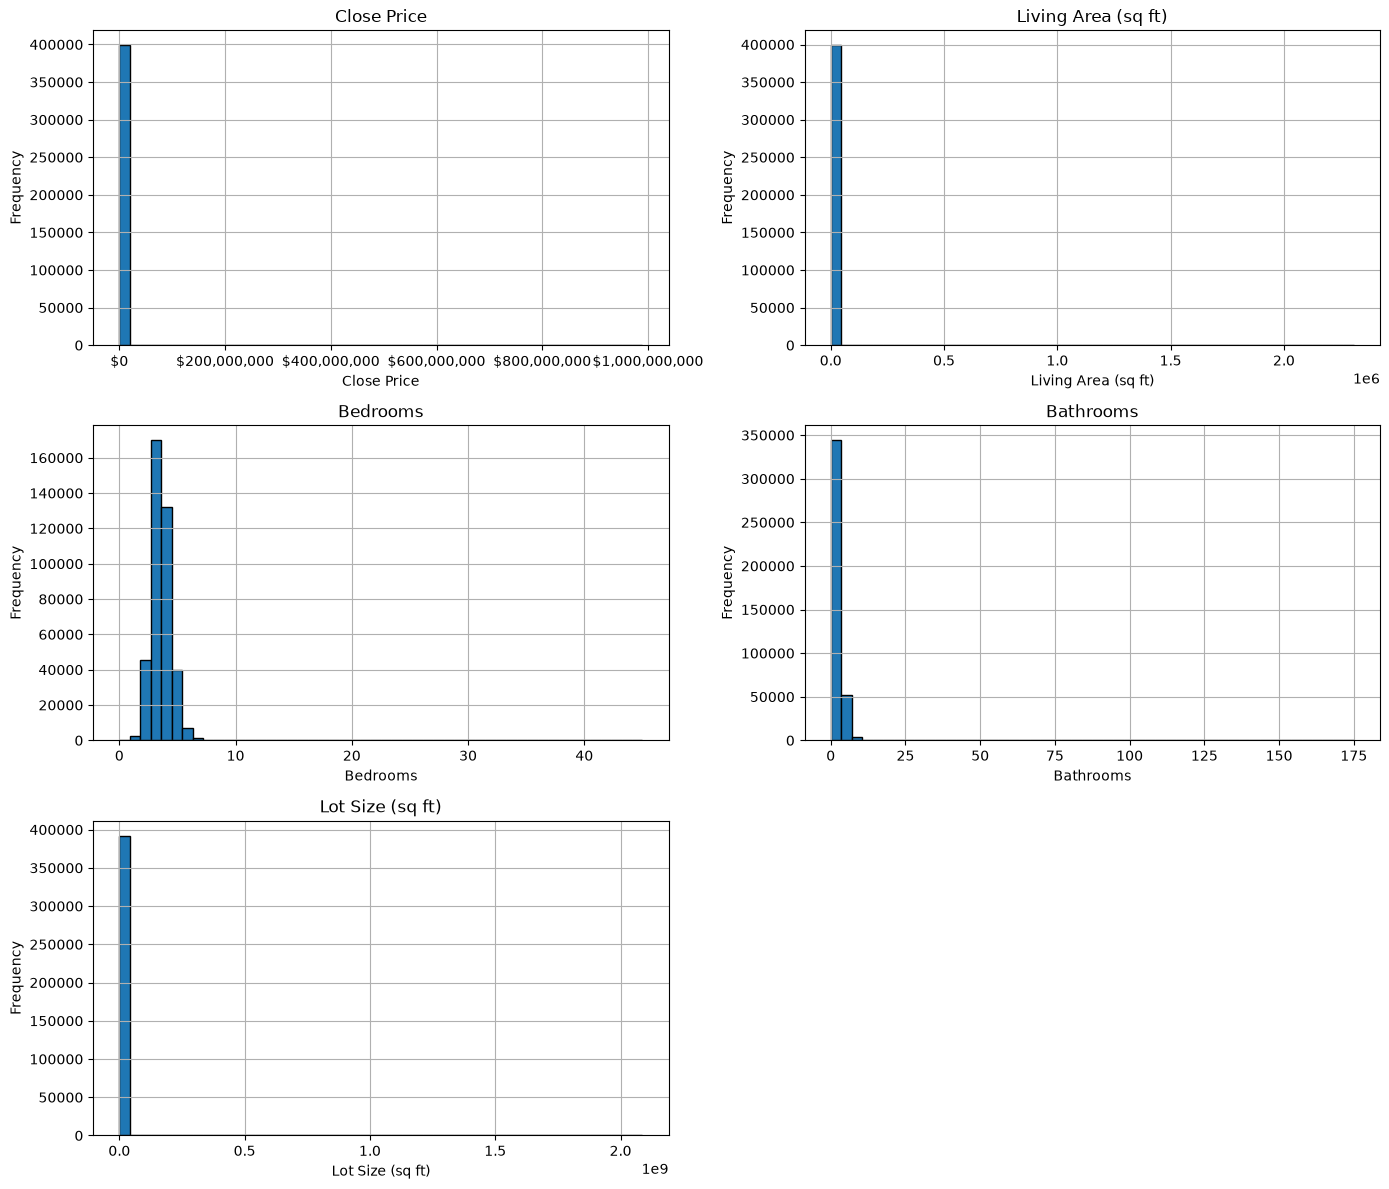

In [38]:
# ============================================
# Histograms of the key variables
# ============================================

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, column in zip(axes, key_columns):
    homes[column].hist(
        bins=50,
        ax=ax,
        edgecolor="black"
    )

    ax.set_title(display_names[column])
    ax.set_xlabel(display_names[column])
    ax.set_ylabel("Frequency")
    if column == "ClosePrice":
        ax.xaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))

# Remove the unused subplot
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

## Boxplots

Boxplots provide another view of each variable by highlighting the median,
interquartile range (IQR), and potential outliers.

These plots are especially useful for identifying variables with highly skewed
distributions.

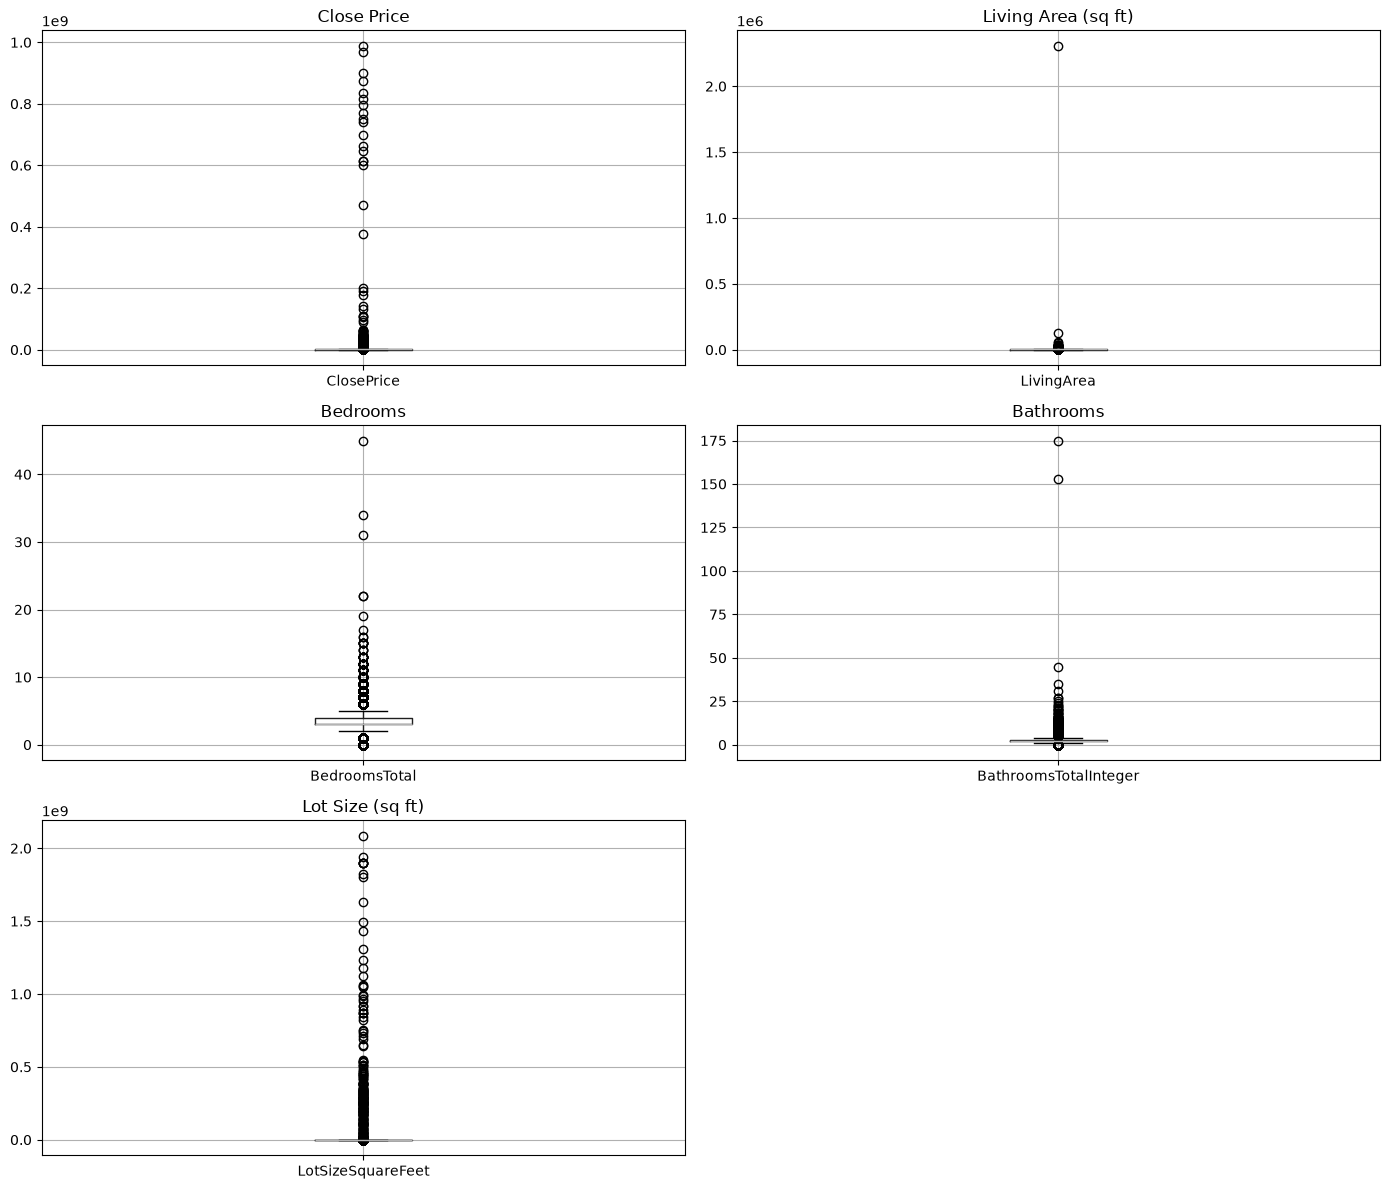

In [39]:
# ============================================
# Boxplots of the key variables
# ============================================

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, column in zip(axes, key_columns):
    homes.boxplot(
        column=column,
        ax=ax
    )

    ax.set_title(display_names[column])
    ax.set_xlabel("")

# Remove unused subplot
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

## Histograms (Central 99% of the Data)

The previous histograms include all observations, including a small number of
extreme values that compress the majority of the data into a narrow range.

To better visualize the typical distribution of each variable, the following
plots exclude only the upper 1% of values for visualization purposes.

**Note:** This filtering is applied only for plotting. No observations are
removed from the dataset.

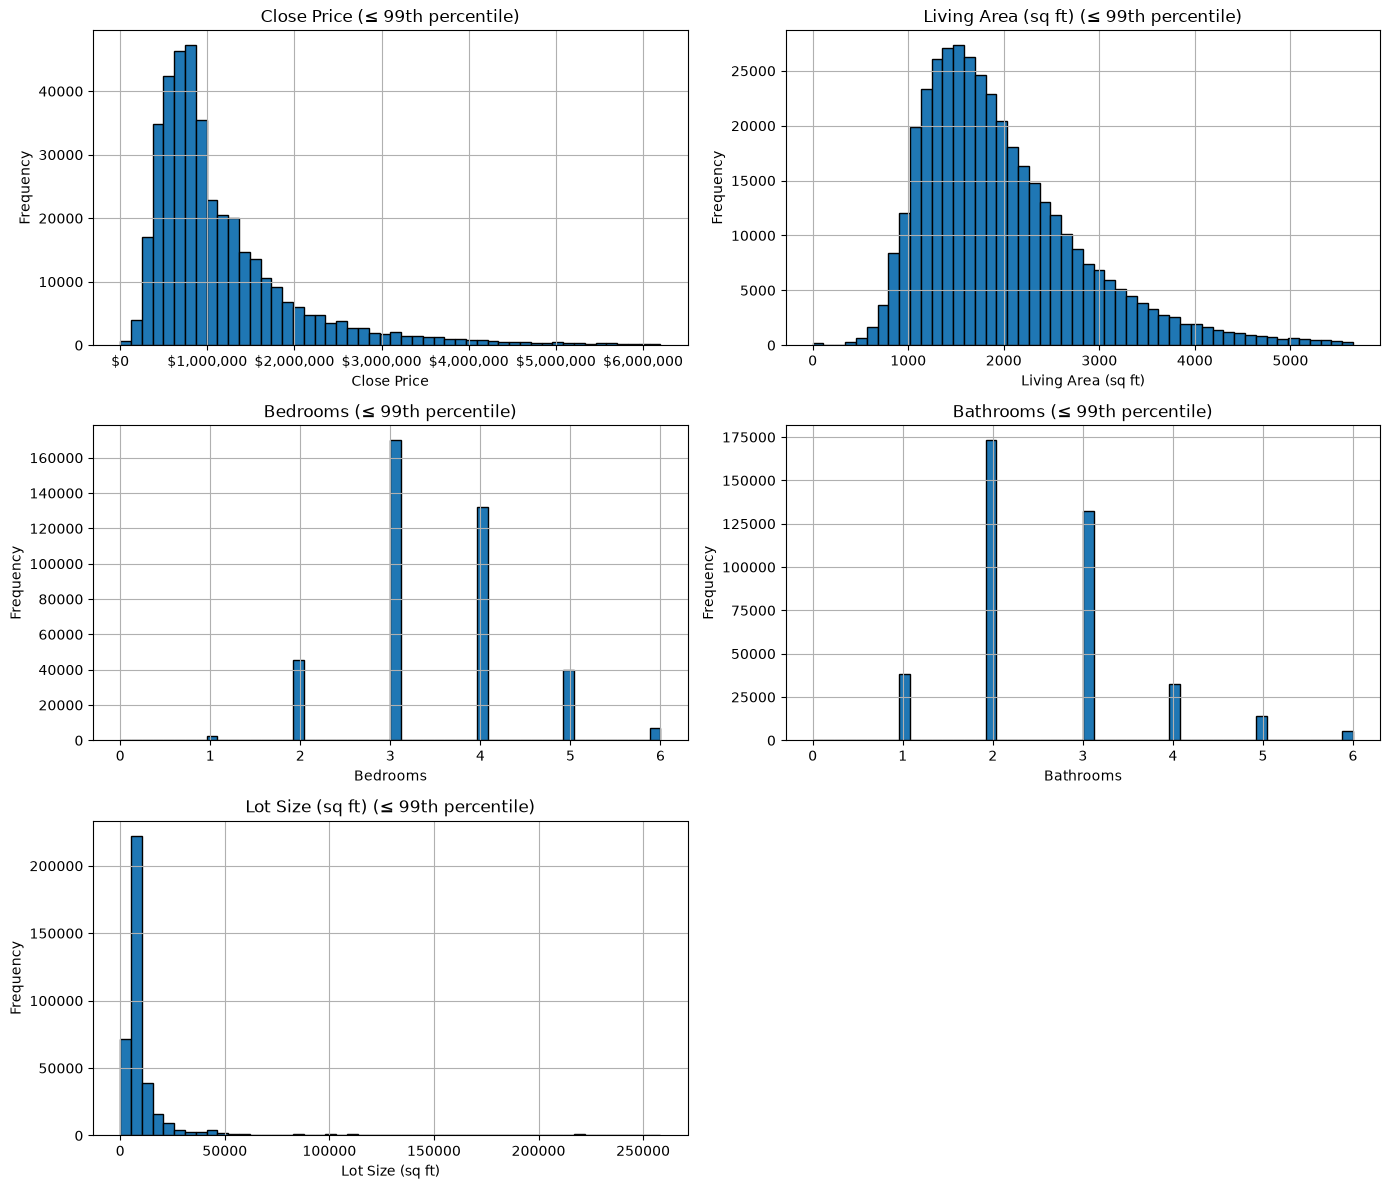

In [40]:
# ============================================
# Histograms of the central 99% of each variable
# (for visualization only)
# ============================================

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, column in zip(axes, key_columns):

    upper_limit = homes[column].quantile(0.99)

    homes.loc[
        homes[column] <= upper_limit,
        column
    ].hist(
        bins=50,
        ax=ax,
        edgecolor="black"
    )

    ax.set_title(f"{display_names[column]} (≤ 99th percentile)")
    ax.set_xlabel(display_names[column])
    ax.set_ylabel("Frequency")
    if column == "ClosePrice":
        ax.xaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))

fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

## Key Findings

The exploratory analysis produced several insights that will inform the
preprocessing and modeling stages of this project.

- After filtering, the dataset contains **399,157** residential single-family
  property sales across the available monthly CRMLS datasets.
- Missing data is minimal for the primary variables. Among the variables
  examined, **LotSizeSquareFeet** has the highest missing rate (1.71%), while
  the remaining variables have negligible missing values.
- **ClosePrice**, **LivingArea**, and **LotSizeSquareFeet** exhibit strongly
  right-skewed distributions with long upper tails, indicating the presence of
  relatively few high-value or unusually large properties.
- Most properties contain **3–4 bedrooms** and **2–3 bathrooms**, representing
  the typical residential home within the dataset.
- The comparison between the full distributions and the central 99% confirms
  that a relatively small number of extreme observations substantially affect
  the scale of several variables. These observations will be investigated during
  the preprocessing stage to determine the most appropriate treatment.

Overall, the exploratory analysis indicates that the dataset is well suited for
predictive modeling. The data contains minimal missing values and exhibits
feature distributions that are consistent with expectations for residential
real estate transactions.

---
Notebook completed for:

IDX Exchange Data Science Internship

Notebook:
01_exploration.ipynb

Author:
Gabriella Gass

Date:
June 2026